# 50.039 Deep Learning Y2026
### Anomaly Detection of Melanoma in Dermoscopic Images
#### Group 16

| Student Name           | Student Number |
|------------------------|----------------|
| Gay Jun Han Dylan      | 1007831        |
| Lydia Rachel Robert    | 1008462        |
| Yeo Chun Sheng Joel    | 1008112        |

### Test HAM10000 Dataset Class

In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.data.dataset import HAM10000Dataset

dataset = HAM10000Dataset(
    csv_path="../data/raw/HAM10000/metadata.csv",
    image_dir="../data/raw/HAM10000/images",
    transform=None
)

print("Dataset size:", len(dataset))

image, label = dataset[0]
print("Label:", label)
print("Image size:", image.size)
print("Image mode:", image.mode)
print()
image, label = dataset[1114]
print("Label:", label)
print("Image size:", image.size)
print("Image mode:", image.mode)

Dataset size: 7818
Label: 1
Image size: (224, 224)
Image mode: RGB

Label: 0
Image size: (224, 224)
Image mode: RGB


### Check ratio of melanoma vs nevus
- **0** : melanoma (anomaly)
- **1** : nevus

In [2]:
import pandas as pd

train = pd.read_csv("../data_new/splits/train.csv")
val = pd.read_csv("../data_new/splits/val.csv")
test = pd.read_csv("../data_new/splits/test.csv")

print("Train label counts:")
print(train["label"].value_counts())

print("\nValidation label counts:")
print(val["label"].value_counts())

print("\nTest label counts:")
print(test["label"].value_counts())

print("Train ratio:")
print(train["label"].value_counts(normalize=True))

print("\nValidation ratio:")
print(val["label"].value_counts(normalize=True))

print("\nTest ratio:")
print(test["label"].value_counts(normalize=True))

Train label counts:
label
0    7114
1     877
Name: count, dtype: int64

Validation label counts:
label
0    1788
1     236
Name: count, dtype: int64

Test label counts:
label
0    1340
1     171
Name: count, dtype: int64
Train ratio:
label
0    0.890252
1    0.109748
Name: proportion, dtype: float64

Validation ratio:
label
0    0.883399
1    0.116601
Name: proportion, dtype: float64

Test ratio:
label
0    0.88683
1    0.11317
Name: proportion, dtype: float64


### Test train dataset class

In [7]:
dataset = HAM10000Dataset(
    csv_path="../data/splits/train.csv",
    image_dir="../data/raw/HAM10000/images",
    transform=None
)

print("Dataset size:", len(dataset))

image, label = dataset[0]

print("Label:", label)
print("Image size:", image.size)

Dataset size: 5472
Label: 0
Image size: (224, 224)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

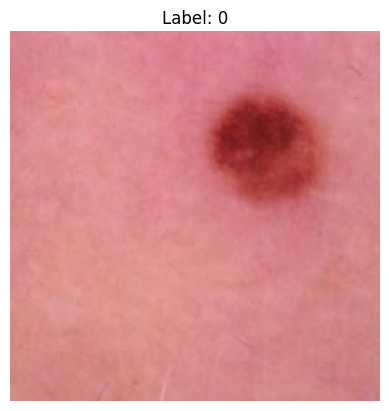

In [8]:
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title(f"Label: {label}")
plt.axis("off")

### Test Transform

In [23]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.data.dataset import HAM10000Dataset
from src.data.transform import get_train_transforms, get_eval_transforms

train_dataset = HAM10000Dataset(
    csv_path="../data/splits/train.csv",
    image_dir="../data/raw/HAM10000/images",
    transform=get_train_transforms()
)

image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
1


### Test with dataloader

In [24]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import torch
from torch.utils.data import DataLoader

from src.data.dataset import HAM10000Dataset
from src.data.transform import get_train_transforms, get_eval_transforms

train_dataset = HAM10000Dataset(
    csv_path="../data/splits/train.csv",
    image_dir="../data/raw/HAM10000/images",
    transform=get_train_transforms()
)

val_dataset = HAM10000Dataset(
    csv_path="../data/splits/val.csv",
    image_dir="../data/raw/HAM10000/images",
    transform=get_eval_transforms()
)

test_dataset = HAM10000Dataset(
    csv_path="../data/splits/test.csv",
    image_dir="../data/raw/HAM10000/images",
    transform=get_eval_transforms()
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Unique labels in batch:", torch.unique(labels))

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Unique labels in batch: tensor([0, 1])


### Test dataloader.py

In [25]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from src.data.dataloader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../data/splits/train.csv",
    val_csv="../data/splits/val.csv",
    test_csv="../data/splits/test.csv",
    image_dir="../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
torch.Size([32])
tensor([1, 1, 1, 1, 1, 1, 1, 0, 1, 1])


In [1]:
import pandas as pd

test_df = pd.read_csv("../data/splits/test.csv")
test_df["label"].value_counts()

label
1    1006
0     167
Name: count, dtype: int64